In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
results = np.load("MC_simulation_results.npy", allow_pickle=True).item()

DKRL
[0.00216050175891304, 0.0008439479332547974, 0.0004687702002461456, 0.0001466205411336219, 7.776794426759921e-05, 2.4710153063590793e-05]
[0.00223456569785567, 0.0013203802262880802, 0.0010407138009462255, 0.0009109577337120161, 0.000710777745746505, 0.0006803797575741708]
[0.00031226920887682984, 0.00010216834848662419, 6.07384090125967e-05, 1.9389565065192137e-05, 1.0281548330526297e-05, 4.513614320806138e-06]
[0.00047165472929038715, 0.00032206729720558777, 0.00033498037222461866, 0.0002877188192862361, 0.00025915195988786423, 0.00026340179037928743]
KZ
[0.000892360787203, 0.000700786638493931, 0.0005777049360702631, 0.0006482162817740175, 0.0005368276722231399, 0.000494875175707733]
[0.00412803448731936, 0.0040934833547886604, 0.003494985840064389, 0.004237756835020475, 0.003632038085098886, 0.0034406867601796034]
[0.0001689534209466487, 0.00025009060903615507, 0.00024101403249952532, 0.00030662487934426057, 0.0002790735868821123, 0.00025580961115037105]
[0.0007730364936202197

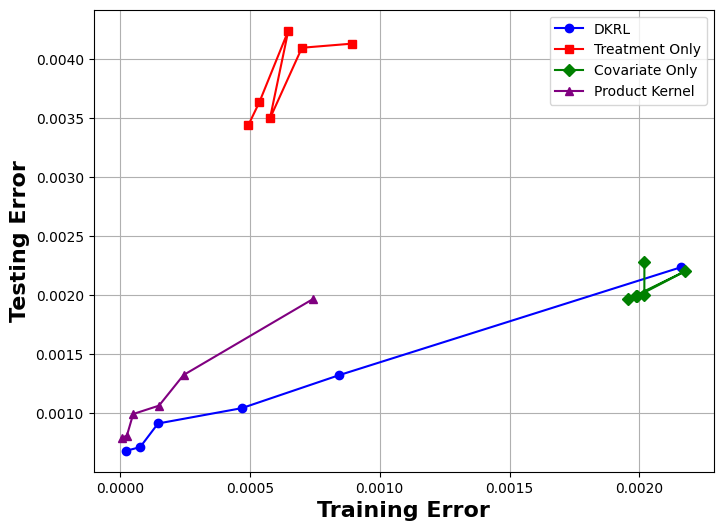

In [14]:
# Define methods, colors, and markers
methods = ["DKRL", "KZ", "KX", "KZX"]
colors = {"DKRL": "blue", "KZ": "red", "KX": "green", "KZX": "purple"}
markers = {"DKRL": "o", "KZ": "s", "KX": "D", "KZX": "^"}
method_labels = {"DKRL": "DKRL", "KZ": "Treatment Only", "KX": "Covariate Only", "KZX": "Product Kernel"}

# Initialize plot
plt.figure(figsize=(8, 6))

# Iterate through methods and collect training vs testing error under different pt_levels
for method in methods:
    train_errs = []
    test_errs = []
    train_stds = []
    test_stds = []
    pt_levels = []

    for pt in results.keys():
        train_err_mean = np.mean(results[pt][method]["train_err"])
        test_err_mean = np.mean(results[pt][method]["test_err"])
        train_err_std = np.std(results[pt][method]["train_err"])
        test_err_std = np.std(results[pt][method]["test_err"])
        train_errs.append(train_err_mean)
        test_errs.append(test_err_mean)
        train_stds.append(train_err_std)
        test_stds.append(test_err_std)
        pt_levels.append(pt)

    print(method)
    print(train_errs)
    print(test_errs)
    print(train_stds)
    print(test_stds)    

    # Plot each method's training vs testing error with different markers
    plt.plot(train_errs, test_errs, marker=markers[method], color=colors[method], linestyle='-', label=method_labels[method])

    # Annotate points with their pt_level values
    # for i, txt in enumerate(pt_levels):
    #     plt.annotate(f"{txt:.1e}", (train_errs[i], test_errs[i]), fontsize=10, color=colors[method])

# Labels, legend, and grid
plt.xlabel("Training Error", fontsize=16, fontweight='bold')
plt.ylabel("Testing Error", fontsize=16, fontweight='bold')
# plt.title("Training Error vs Testing Error for Different Methods")
plt.legend()
plt.grid(True)

# save 
plt.savefig("train-test.png")

# Show the plot
plt.show()

<Figure size 640x480 with 0 Axes>